<a href="https://colab.research.google.com/github/minasaeday14/INFO-5731-spring-2026/blob/main/INFO5731_Assignment_3_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **INFO5731 Assignment 3**

**This exercise will provide a valuable learning experience in working with text data and extracting features using various topic modeling algorithms. Key concepts such as Latent Dirichlet Allocation (LDA), Latent Semantic Analysis (LSA) and BERTopic.**



**Expectations**:

*   Use the provided .*ipynb* document to write your code & respond to the questions. Avoid generating a new file.
*   Write complete answers and run all the cells before submission.
*   Make sure the submission is "clean"; *i.e.*, no unnecessary code cells.
*   Once finished, allow shared rights from top right corner (*see Canvas for details*).

**Total points**: 100


NOTE: The output should be presented well to get **full points**

**Late submissions will have a penalty of 10% of the marks for each day of late submission, and no requests will be answered. Manage your time accordingly.**


# **Question 1 (20 Points)**

**Dataset**: 20 Newsgroups dataset

**Dataset Link**: https://scikit-learn.org/0.19/datasets/twenty_newsgroups.html

**Consider Random 2000 rows only**

Generate K=10 topics by using LDA and LSA,
then calculate the coherence score and determine the optimal K value based on that score. Further, summarize and visualize each topic in your own words.


In [ ]:
!pip install -q gensim


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 47.4 MB/s eta 0:00:00


Documents retained after cleaning: 1925
Vocabulary size for coherence calculation: 27978


,K,LDA Coherence,LSA Coherence
0,2,0.4472,0.3875
1,3,0.5629,0.3612
2,4,0.5946,0.3912
3,5,0.5910,0.4013
4,6,0.5323,0.3674
5,7,0.5522,0.4588
6,8,0.5421,0.4412
7,9,0.5510,0.4093
8,10,0.5435,0.4077
9,11,0.4990,0.3850


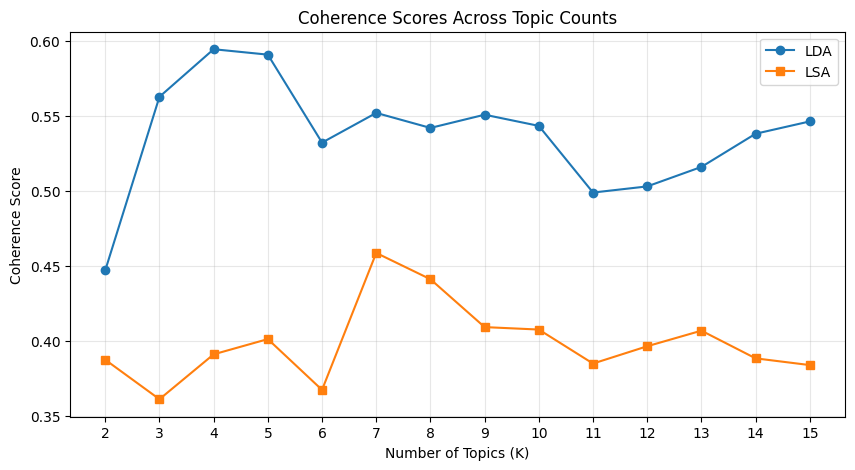

Best LDA topic count by coherence: K = 4
Best LSA topic count by coherence: K = 7
LDA topics for K = 10


,Topic,Top Words,Summary
0,Topic 1,"don, game, like, just, good, year, team, think, got, car","This topic mainly discusses don, game, like. Supporting terms include just, good, year."
1,Topic 2,"key, encryption, des, chip, data, used, use, clipper, bit, new","This topic mainly discusses key, encryption, des. Supporting terms include chip, data, used."
2,Topic 3,"files, mac, file, entry, use, disk, program, need, software, ftp","This topic mainly discusses files, mac, file. Supporting terms include entry, use, disk."
3,Topic 4,"people, know, think, don, just, say, like, going, right, did","This topic mainly discusses people, know, think. Supporting terms include don, just, say."
4,Topic 5,"know, drive, like, thanks, card, does, problem, just, time, com","This topic mainly discusses know, drive, like. Supporting terms include thanks, card, does."
5,Topic 6,"image, use, window, windows, file, openwindows, using, edu, sun, display","This topic mainly discusses image, use, window. Supporting terms include windows, file, openwindows."
6,Topic 7,"god, people, don, does, just, believe, know, like, think, church","This topic mainly discusses god, people, don. Supporting terms include does, just, believe."
7,Topic 8,"turkish, armenian, armenians, people, health, turks, new, said, russian, population","This topic mainly discusses turkish, armenian, armenians. Supporting terms include people, health, turks."
8,Topic 9,"space, edu, com, list, pit, like, nasa, news, year, just","This topic mainly discusses space, edu, com. Supporting terms include list, pit, like."
9,Topic 10,"fbi, greek, batf, koresh, government, atf, university, agents, weapons, members","This topic mainly discusses fbi, greek, batf. Supporting terms include koresh, government, atf."


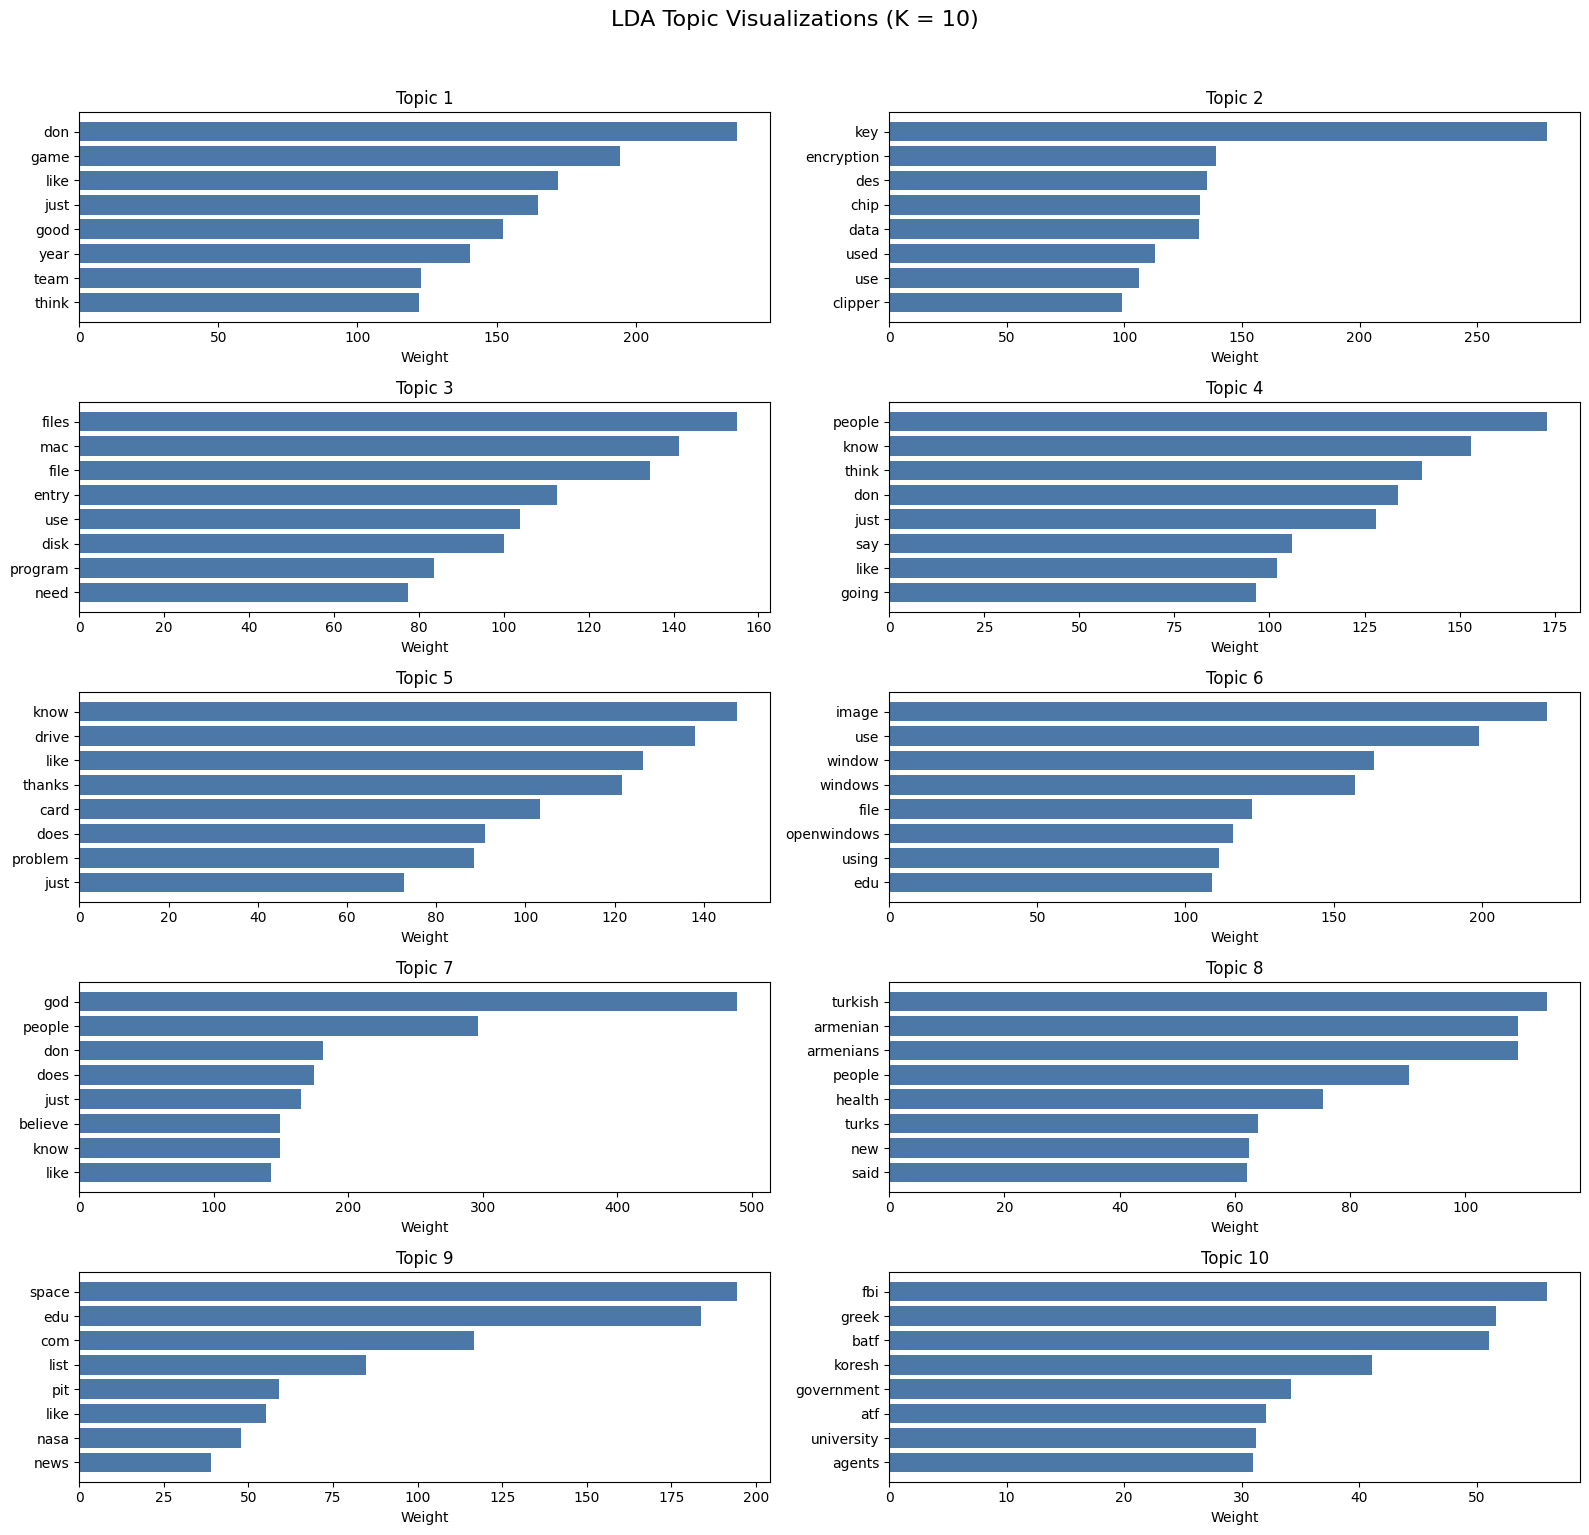

LSA topics for K = 10


,Topic,Top Words,Summary
0,Topic 1,"don, like, just, know, people, think, does, god, use, time","This topic mainly discusses don, like, just. Supporting terms include know, people, think."
1,Topic 2,"god, thanks, windows, drive, people, card, file, com, files, help","This topic mainly discusses god, thanks, windows. Supporting terms include drive, people, card."
2,Topic 3,"god, game, thanks, team, year, jesus, does, windows, hockey, believe","This topic mainly discusses god, game, thanks. Supporting terms include team, year, jesus."
3,Topic 4,"key, game, drive, encryption, chip, clipper, keys, des, government, god","This topic mainly discusses key, game, drive. Supporting terms include encryption, chip, clipper."
4,Topic 5,"drive, thanks, scsi, hard, drives, game, disk, windows, file, edu","This topic mainly discusses drive, thanks, scsi. Supporting terms include hard, drives, game."
5,Topic 6,"game, god, key, team, edu, just, know, car, win, shameful","This topic mainly discusses game, god, key. Supporting terms include team, edu, just."
6,Topic 7,"edu, shameful, cadre, pitt, jxp, geb, skepticism, chastity, dsl, intellect","This topic mainly discusses edu, shameful, cadre. Supporting terms include pitt, jxp, geb."
7,Topic 8,"thanks, windows, god, list, mail, file, new, sale, files, think","This topic mainly discusses thanks, windows, god. Supporting terms include list, mail, file."
8,Topic 9,"list, armenians, drive, armenian, car, com, don, people, know, think","This topic mainly discusses list, armenians, drive. Supporting terms include armenian, car, com."
9,Topic 10,"thanks, know, does, com, new, drive, game, don, window, edu","This topic mainly discusses thanks, know, does. Supporting terms include com, new, drive."


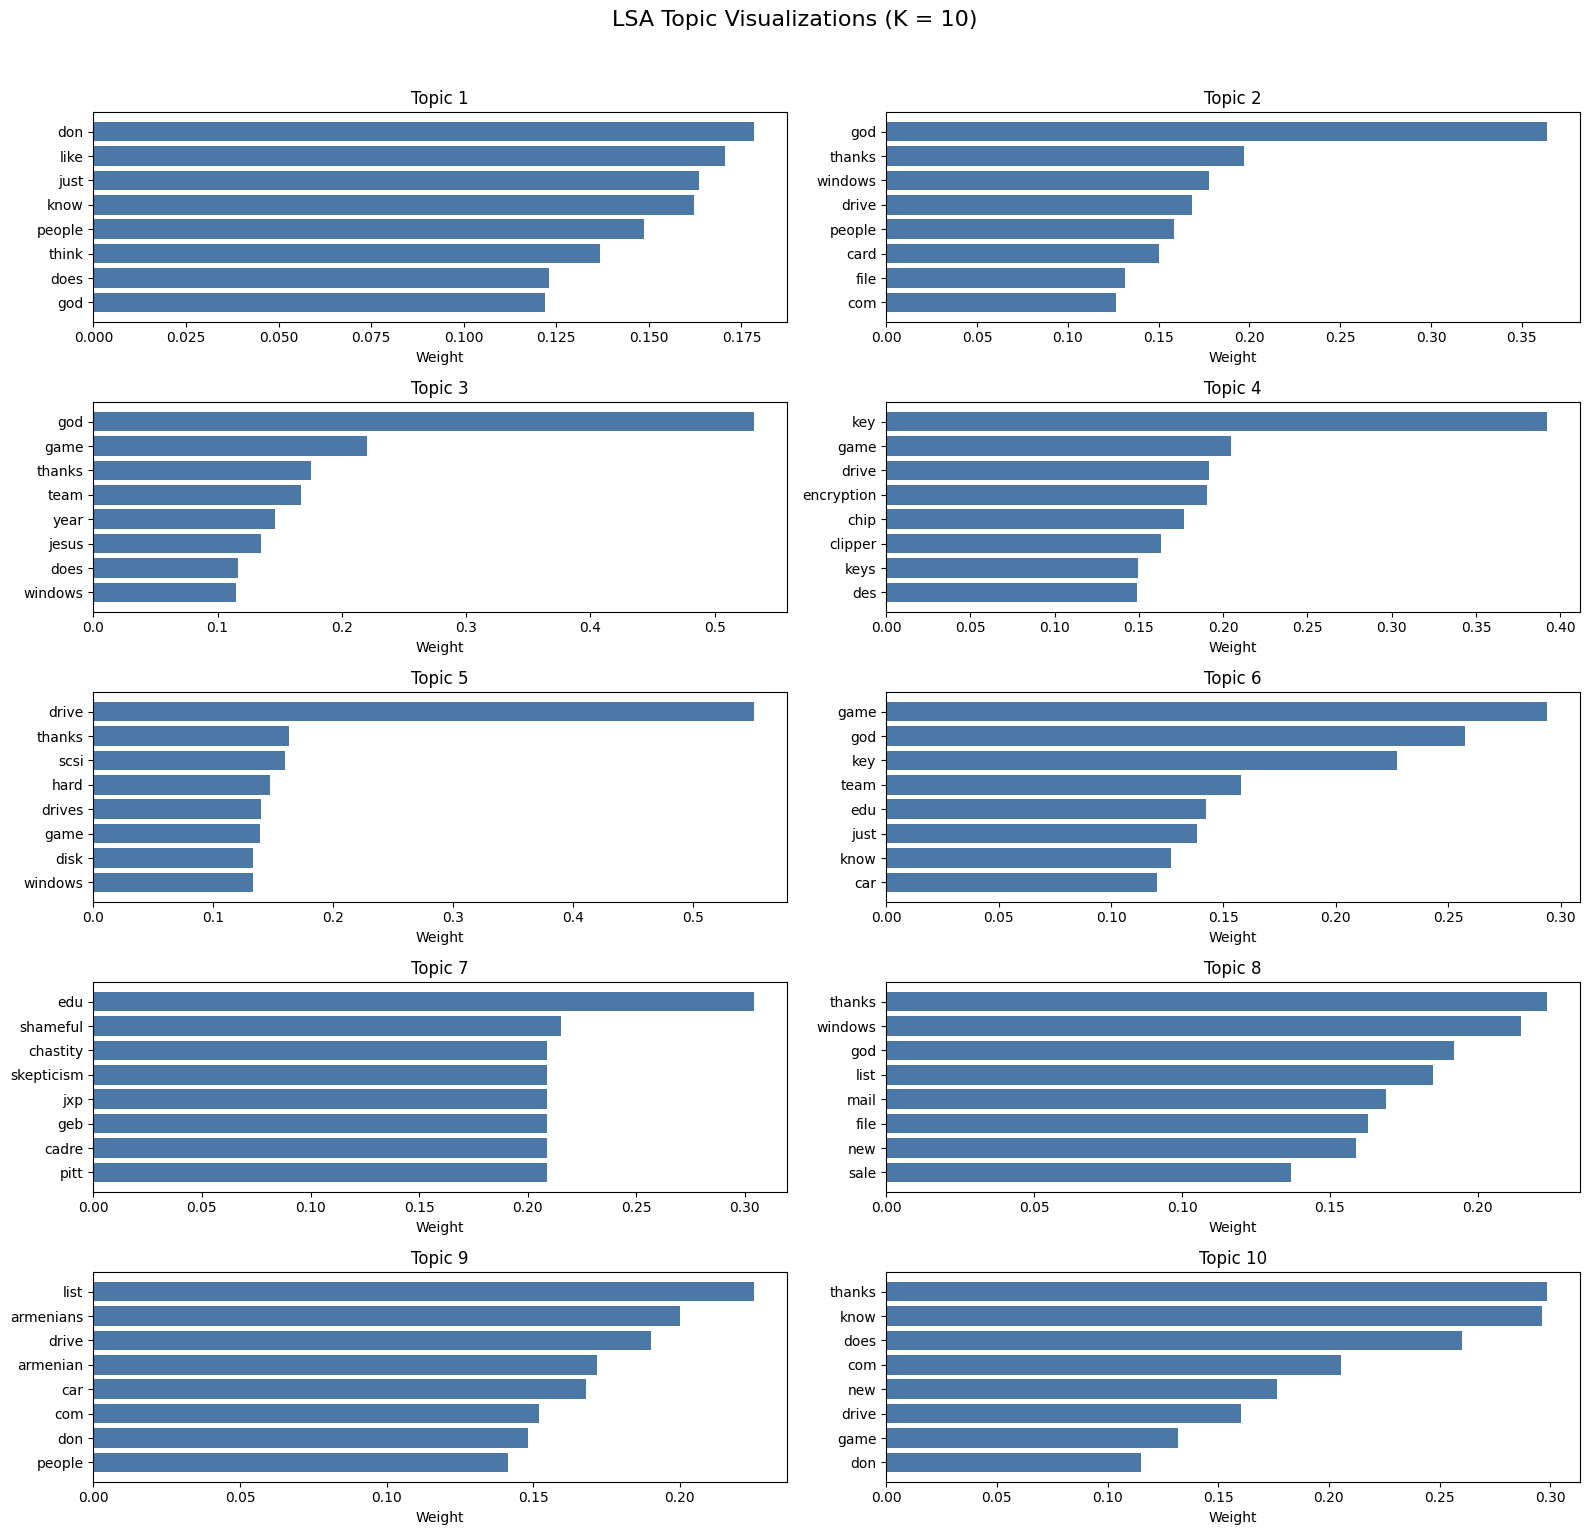

In [ ]:
import os
import re
import warnings
from pathlib import Path

import numpy as np
import pandas as pd

os.environ["XDG_CACHE_HOME"] = str(Path.cwd() / ".cache")
Path(os.environ["XDG_CACHE_HOME"]).mkdir(parents=True, exist_ok=True)
os.environ["MPLCONFIGDIR"] = str(Path.cwd() / ".mplconfig")
Path(os.environ["MPLCONFIGDIR"]).mkdir(parents=True, exist_ok=True)

import matplotlib.pyplot as plt
from IPython.display import display
from gensim.corpora import Dictionary
from gensim.models import CoherenceModel
from sklearn.datasets import fetch_20newsgroups
from sklearn.decomposition import LatentDirichletAllocation, TruncatedSVD
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

warnings.filterwarnings("ignore")
pd.set_option("display.max_colwidth", None)


def clean_text(text):
    text = re.sub(r"[^a-zA-Z\s]", " ", str(text).lower())
    return re.sub(r"\s+", " ", text).strip()


def tokenize_for_coherence(text):
    return [token for token in clean_text(text).split() if len(token) > 2]


def summarize_topic(words):
    lead_terms = ", ".join(words[:3])
    supporting_terms = ", ".join(words[3:6])
    return (
        f"This topic mainly discusses {lead_terms}. "
        f"Supporting terms include {supporting_terms}."
    )


def extract_topics(model, feature_names, top_n=10, use_absolute=False):
    topics = []
    topic_weights = []

    for component in model.components_:
        ranking_vector = np.abs(component) if use_absolute else component
        top_indices = np.argsort(ranking_vector)[::-1][:top_n]
        topics.append([feature_names[index] for index in top_indices])
        topic_weights.append(ranking_vector[top_indices])

    return topics, topic_weights


def coherence_score(topic_words, tokenized_docs, dictionary):
    coherence_model = CoherenceModel(
        topics=topic_words,
        texts=tokenized_docs,
        dictionary=dictionary,
        coherence="c_v",
        processes=1,
    )
    return coherence_model.get_coherence()


def plot_coherence_scores(results_df):
    plt.figure(figsize=(10, 5))
    plt.plot(results_df["K"], results_df["LDA Coherence"], marker="o", label="LDA")
    plt.plot(results_df["K"], results_df["LSA Coherence"], marker="s", label="LSA")
    plt.xlabel("Number of Topics (K)")
    plt.ylabel("Coherence Score")
    plt.title("Coherence Scores Across Topic Counts")
    plt.xticks(results_df["K"])
    plt.grid(alpha=0.3)
    plt.legend()
    plt.show()


def plot_topic_terms(topic_words, topic_weights, title):
    n_topics = len(topic_words)
    n_cols = 2
    n_rows = int(np.ceil(n_topics / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 3 * n_rows))
    axes = np.array(axes).reshape(-1)

    for idx, ax in enumerate(axes):
        if idx >= n_topics:
            ax.axis("off")
            continue

        words = topic_words[idx][:8]
        weights = np.array(topic_weights[idx][:8])
        order = np.argsort(weights)
        ax.barh(np.array(words)[order], weights[order], color="#4C78A8")
        ax.set_title(f"Topic {idx + 1}")
        ax.set_xlabel("Weight")

    fig.suptitle(title, fontsize=16, y=1.02)
    plt.tight_layout()
    plt.show()


random_state = 42
sample_size = 2000
k_values = list(range(2, 16))
top_n_words = 10

cache_dir = Path.cwd() / "scikit_learn_data"
cache_dir.mkdir(parents=True, exist_ok=True)

try:
    newsgroups = fetch_20newsgroups(
        subset="all",
        remove=("headers", "footers", "quotes"),
        data_home=str(cache_dir),
    )
except Exception as exc:
    raise RuntimeError(
        "The 20 Newsgroups dataset is not available locally. "
        "Run this notebook once in an environment with internet access so "
        "scikit-learn can cache the dataset in the notebook folder."
    ) from exc

rng = np.random.default_rng(random_state)
sample_indices = rng.choice(len(newsgroups.data), size=sample_size, replace=False)
raw_documents = [newsgroups.data[index] for index in sample_indices]

processed_documents = []
for doc in raw_documents:
    tokens = tokenize_for_coherence(doc)
    if len(tokens) >= 5:
        processed_documents.append(" ".join(tokens))

tokenized_docs = [doc.split() for doc in processed_documents]
dictionary = Dictionary(tokenized_docs)

print(f"Documents retained after cleaning: {len(processed_documents)}")
print(f"Vocabulary size for coherence calculation: {len(dictionary)}")

count_vectorizer = CountVectorizer(
    stop_words="english",
    max_df=0.7,
    min_df=5,
    max_features=5000,
)
count_matrix = count_vectorizer.fit_transform(processed_documents)
count_features = count_vectorizer.get_feature_names_out()

tfidf_vectorizer = TfidfVectorizer(
    stop_words="english",
    max_df=0.7,
    min_df=5,
    max_features=5000,
)
tfidf_matrix = tfidf_vectorizer.fit_transform(processed_documents)
tfidf_features = tfidf_vectorizer.get_feature_names_out()

coherence_rows = []
for k in k_values:
    lda_model = LatentDirichletAllocation(
        n_components=k,
        random_state=random_state,
        learning_method="batch",
        max_iter=15,
    )
    lda_model.fit(count_matrix)
    lda_topics, _ = extract_topics(lda_model, count_features, top_n=top_n_words)
    lda_coherence = coherence_score(lda_topics, tokenized_docs, dictionary)

    lsa_model = TruncatedSVD(n_components=k, random_state=random_state)
    lsa_model.fit(tfidf_matrix)
    lsa_topics, _ = extract_topics(
        lsa_model,
        tfidf_features,
        top_n=top_n_words,
        use_absolute=True,
    )
    lsa_coherence = coherence_score(lsa_topics, tokenized_docs, dictionary)

    coherence_rows.append(
        {
            "K": k,
            "LDA Coherence": lda_coherence,
            "LSA Coherence": lsa_coherence,
        }
    )

results_df = pd.DataFrame(coherence_rows)
display(results_df.round(4))
plot_coherence_scores(results_df)

best_lda_k = int(results_df.loc[results_df["LDA Coherence"].idxmax(), "K"])
best_lsa_k = int(results_df.loc[results_df["LSA Coherence"].idxmax(), "K"])

print(f"Best LDA topic count by coherence: K = {best_lda_k}")
print(f"Best LSA topic count by coherence: K = {best_lsa_k}")

lda_k10 = LatentDirichletAllocation(
    n_components=10,
    random_state=random_state,
    learning_method="batch",
    max_iter=15,
)
lda_k10.fit(count_matrix)
lda_topics_10, lda_weights_10 = extract_topics(lda_k10, count_features, top_n=top_n_words)

lsa_k10 = TruncatedSVD(n_components=10, random_state=random_state)
lsa_k10.fit(tfidf_matrix)
lsa_topics_10, lsa_weights_10 = extract_topics(
    lsa_k10,
    tfidf_features,
    top_n=top_n_words,
    use_absolute=True,
)

lda_summary_df = pd.DataFrame(
    {
        "Topic": [f"Topic {idx}" for idx in range(1, 11)],
        "Top Words": [", ".join(words) for words in lda_topics_10],
        "Summary": [summarize_topic(words) for words in lda_topics_10],
    }
)

lsa_summary_df = pd.DataFrame(
    {
        "Topic": [f"Topic {idx}" for idx in range(1, 11)],
        "Top Words": [", ".join(words) for words in lsa_topics_10],
        "Summary": [summarize_topic(words) for words in lsa_topics_10],
    }
)

print("LDA topics for K = 10")
display(lda_summary_df)
plot_topic_terms(lda_topics_10, lda_weights_10, "LDA Topic Visualizations (K = 10)")

print("LSA topics for K = 10")
display(lsa_summary_df)
plot_topic_terms(lsa_topics_10, lsa_weights_10, "LSA Topic Visualizations (K = 10)")


# **BERTopic**

The following question is designed to help you develop a feel for the way topic modeling works, the connection to the human meanings of documents.

Dataset from **Assignment 2** (text dataset).

> Dont use any custom datasets.


> Dataset must have 1000+ rows, no duplicates and null values



# **Question 2 (20 Points)**



Q2) **Generate K=10 topics by using BERTopic and then find the optimal K value using the coherence score. Interpret each topic and visualize the results appropriately.**

In [ ]:
!pip install -q bertopic sentence-transformers umap-learn hdbscan gensim plotly


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.7/154.7 kB 3.2 MB/s eta 0:00:00


In [ ]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display
from bertopic import BERTopic
from sentence_transformers import SentenceTransformer
from sklearn.feature_extraction.text import CountVectorizer
from gensim.corpora import Dictionary
from gensim.models import CoherenceModel


In [ ]:
# Load Assignment 2 dataset
df = pd.read_csv("/content/q1_imdb_reviews_raw.csv")

# Use the cleaned text column from Assignment 2
text_col = "clean_text"

# Required checks from prompt
df = df[[text_col]].dropna().drop_duplicates()
df[text_col] = df[text_col].astype(str).str.strip()
df = df[df[text_col] != ""]

print("Rows after cleaning:", len(df))
print("Duplicate rows:", df.duplicated().sum())
print("Null values:", df.isnull().sum().sum())

assert len(df) >= 1000, "Dataset must have 1000+ rows."

docs = df[text_col].tolist()


Rows after cleaning: 1000
Duplicate rows: 0
Null values: 0


In [ ]:
def simple_tokenize(text):
    text = re.sub(r"[^a-zA-Z\s]", " ", str(text).lower())
    return [w for w in text.split() if len(w) > 2]

tokenized_docs = [simple_tokenize(doc) for doc in docs]
dictionary = Dictionary(tokenized_docs)
dictionary.filter_extremes(no_below=5, no_above=0.7)


In [ ]:
def get_topic_words(topic_model, dictionary, top_n=10):
    topic_word_lists = []
    for topic_id in topic_model.get_topics():
        if topic_id == -1:
            continue
        words = [word for word, _ in topic_model.get_topic(topic_id)[:top_n] if word in dictionary.token2id]
        if len(words) >= 3:
            topic_word_lists.append(words)
    return topic_word_lists

def compute_coherence(topic_model, tokenized_docs, dictionary):
    topic_words = get_topic_words(topic_model, dictionary, top_n=10)
    coherence_model = CoherenceModel(
        topics=topic_words,
        texts=tokenized_docs,
        dictionary=dictionary,
        coherence="c_v",
        processes=1
    )
    return coherence_model.get_coherence()

def interpret_topic(words):
    top_terms = ", ".join(words[:5])
    return f"This topic mainly discusses {top_terms} in IMDb movie reviews."


In [ ]:
# Precompute embeddings once to speed up all BERTopic runs
embedding_model = SentenceTransformer("all-MiniLM-L6-v2")
embeddings = embedding_model.encode(docs, show_progress_bar=True)

vectorizer_model = CountVectorizer(
    stop_words="english",
    min_df=5,
    ngram_range=(1, 2)
)


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/32 [00:00<?, ?it/s]

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer

vectorizer_model = CountVectorizer(
    stop_words="english",
    min_df=2,
    max_df=0.95,
    ngram_range=(1, 2)
)


In [ ]:
# Part 1: BERTopic with K = 10
topic_model_10 = BERTopic(
    embedding_model=embedding_model,
    vectorizer_model=vectorizer_model,
    nr_topics=10,
    calculate_probabilities=False,
    verbose=False
)

topics_10, probs_10 = topic_model_10.fit_transform(docs, embeddings)

topic_info_10 = topic_model_10.get_topic_info()
display(topic_info_10)


Topic  Count                                 Name  \
0     -1    109        -1_blind_social_cheesi_pillar   
1      0    273            0_blend_al_lisan_lisan al   
2      1    618  1_watch imax_start finish_uniqu_edg   

                                                                                              Representation  \
0  [blind, social, cheesi, pillar, everybodi el, film histori, met, say like, look amaz, act cinematographi]   
1                                      [blend, al, lisan, lisan al, delv, gaib, al gaib, purpos, learn, age]   
2          [watch imax, start finish, uniqu, edg, blockbust, edg seat, recommend watch, non, kind movi, ago]   

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                 

In [ ]:
topic_rows = []

for topic_id in topic_info_10["Topic"]:
    if topic_id == -1:
        continue
    words = [word for word, _ in topic_model_10.get_topic(topic_id)[:10]]
    topic_rows.append({
        "Topic": topic_id,
        "Top Words": ", ".join(words),
        "Interpretation": interpret_topic(words)
    })

topic_summary_df = pd.DataFrame(topic_rows)
display(topic_summary_df)


,Topic,Top Words,Interpretation
0,0,"blend, al, lisan, lisan al, delv, gaib, al gaib, purpos, learn, age","This topic mainly discusses blend, al, lisan, lisan al, delv in IMDb movie reviews."
1,1,"watch imax, start finish, uniqu, edg, blockbust, edg seat, recommend watch, non, kind movi, ago","This topic mainly discusses watch imax, start finish, uniqu, edg, blockbust in IMDb movie reviews."


In [ ]:
# Visualize K=10 topics
topic_model_10.visualize_barchart(top_n_topics=10)


In [ ]:
topic_info_10 = topic_model_10.get_topic_info()
valid_topics = topic_info_10[topic_info_10["Topic"] != -1]

display(valid_topics)

print(f"Number of valid topics: {len(valid_topics)}")
print("Skipping visualize_topics() because it is failing for this model.")


Topic  Count                                 Name  \
1      0    273            0_blend_al_lisan_lisan al   
2      1    618  1_watch imax_start finish_uniqu_edg   

                                                                                      Representation  \
1                              [blend, al, lisan, lisan al, delv, gaib, al gaib, purpos, learn, age]   
2  [watch imax, start finish, uniqu, edg, blockbust, edg seat, recommend watch, non, kind movi, ago]   

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                 

Number of valid topics: 2
Skipping visualize_topics() because it is failing for this model.


In [ ]:
candidate_k = list(range(5, 16))
results = []

for k in candidate_k:
    model = BERTopic(
        embedding_model=embedding_model,
        vectorizer_model=vectorizer_model,
        nr_topics=k,
        calculate_probabilities=False,
        verbose=False
    )

    model.fit_transform(docs, embeddings)
    coherence = compute_coherence(model, tokenized_docs, dictionary)
    actual_topics = len([t for t in model.get_topics().keys() if t != -1])

    results.append({
        "Requested K": k,
        "Actual Topics": actual_topics,
        "Coherence Score": coherence
    })

results_df = pd.DataFrame(results)
display(results_df)


,Requested K,Actual Topics,Coherence Score
0,5,2,0.431014
1,6,2,0.404918
2,7,2,0.464509
3,8,2,0.378474
4,9,2,0.344194
5,10,4,0.243673
6,11,2,0.278671
7,12,3,0.255110
8,13,2,0.365037
9,14,2,0.380086


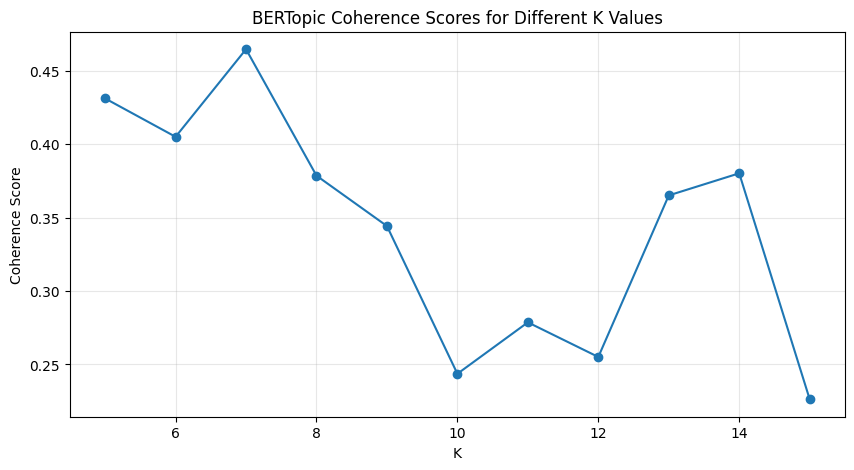

Optimal K based on coherence score: 7


In [ ]:
# Plot coherence scores
plt.figure(figsize=(10, 5))
plt.plot(results_df["Requested K"], results_df["Coherence Score"], marker="o")
plt.xlabel("K")
plt.ylabel("Coherence Score")
plt.title("BERTopic Coherence Scores for Different K Values")
plt.grid(True, alpha=0.3)
plt.show()

best_k = int(results_df.loc[results_df["Coherence Score"].idxmax(), "Requested K"])
print("Optimal K based on coherence score:", best_k)


In [ ]:
# Retrain BERTopic with the best K
best_topic_model = BERTopic(
    embedding_model=embedding_model,
    vectorizer_model=vectorizer_model,
    nr_topics=best_k,
    calculate_probabilities=False,
    verbose=False
)

best_topics, best_probs = best_topic_model.fit_transform(docs, embeddings)

best_info = best_topic_model.get_topic_info()
display(best_info)


Topic  Count                                                     Name  \
0     -1    114  -1_social_charact stori_perform rebecca_dune disappoint   
1      0    275                           0_instal_fraser_religion_blend   
2      1    611                 1_watch imax_start finish_creativ_instal   

                                                                                                                       Representation  \
0  [social, charact stori, perform rebecca, dune disappoint, everybodi el, met, say like, rever, act cinematographi, visual storytel]   
1                                                [instal, fraser, religion, blend, greig fraser, nuanc, greig, lisan, lisan al, delv]   
2                                         [watch imax, start finish, creativ, instal, uniqu, blockbust, non, kind movi, ago, stellar]   

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                             

In [ ]:
# Interpret optimal topics
best_rows = []

for topic_id in best_info["Topic"]:
    if topic_id == -1:
        continue
    words = [word for word, _ in best_topic_model.get_topic(topic_id)[:10]]
    best_rows.append({
        "Topic": topic_id,
        "Top Words": ", ".join(words),
        "Interpretation": interpret_topic(words)
    })

best_summary_df = pd.DataFrame(best_rows)
display(best_summary_df)


,Topic,Top Words,Interpretation
0,0,"instal, fraser, religion, blend, greig fraser, nuanc, greig, lisan, lisan al, delv","This topic mainly discusses instal, fraser, religion, blend, greig fraser in IMDb movie reviews."
1,1,"watch imax, start finish, creativ, instal, uniqu, blockbust, non, kind movi, ago, stellar","This topic mainly discusses watch imax, start finish, creativ, instal, uniqu in IMDb movie reviews."


In [ ]:
# Visualize optimal-topic model
best_topic_model.visualize_barchart(top_n_topics=10)


In [ ]:
best_info = best_topic_model.get_topic_info()
best_valid_topics = best_info[best_info["Topic"] != -1]

display(best_valid_topics)
print(f"Number of valid topics: {len(best_valid_topics)}")
print("Skipping visualize_topics() because it fails for this BERTopic result.")


Topic  Count                                      Name  \
1      0    275            0_instal_fraser_religion_blend   
2      1    611  1_watch imax_start finish_creativ_instal   

                                                                                Representation  \
1         [instal, fraser, religion, blend, greig fraser, nuanc, greig, lisan, lisan al, delv]   
2  [watch imax, start finish, creativ, instal, uniqu, blockbust, non, kind movi, ago, stellar]   

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                    

Number of valid topics: 2
Skipping visualize_topics() because it fails for this BERTopic result.


# **Question 3 (25 points)**


**Dataset Link**: 20 Newsgroups Dataset (Random 2000 values)

Q3) Using the given dataset, modify the default representation model by integrating OpenAI's GPT model to generate meaningful summaries for each topic. Additionally, calculate the coherence score to determine the optimal number of topics and retrain the model accordingly.



Useful Link: https://maartengr.github.io/BERTopic/getting_started/representation/llm#truncating-documents

In [ ]:
!pip install -q bertopic sentence-transformers umap-learn hdbscan gensim openai tiktoken plotly


In [ ]:
import os, getpass
os.environ["OPENAI_API_KEY"] = getpass.getpass("Enter your OPENAI_API_KEY: ")


Enter your OPENAI_API_KEY: ··········


In [ ]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display
from openai import OpenAI as OpenAIClient
from bertopic import BERTopic
from bertopic.representation import OpenAI as BERTopicOpenAI
from sentence_transformers import SentenceTransformer
from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import CountVectorizer
from gensim.corpora import Dictionary
from gensim.models import CoherenceModel


In [ ]:
def clean_text(text):
    text = str(text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

def tokenize_for_coherence(text):
    text = re.sub(r"[^a-zA-Z\s]", " ", str(text).lower())
    return [w for w in text.split() if len(w) > 2]

def compute_coherence(topic_model, tokenized_docs, dictionary, top_n=10):
    topic_words = []
    for topic_id, terms in topic_model.get_topics().items():
        if topic_id == -1 or not terms:
            continue
        words = [word for word, _ in terms[:top_n] if word in dictionary.token2id]
        if len(words) >= 3:
            topic_words.append(words)

    if not topic_words:
        return np.nan

    cm = CoherenceModel(
        topics=topic_words,
        texts=tokenized_docs,
        dictionary=dictionary,
        coherence="c_v",
        processes=1
    )
    return cm.get_coherence()


In [ ]:
def clean_text(text):
    text = str(text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

def tokenize_for_coherence(text):
    text = re.sub(r"[^a-zA-Z\s]", " ", str(text).lower())
    return [w for w in text.split() if len(w) > 2]

def compute_coherence(topic_model, tokenized_docs, dictionary, top_n=10):
    topic_words = []
    for topic_id, terms in topic_model.get_topics().items():
        if topic_id == -1 or not terms:
            continue
        words = [word for word, _ in terms[:top_n] if word in dictionary.token2id]
        if len(words) >= 3:
            topic_words.append(words)

    if not topic_words:
        return np.nan

    cm = CoherenceModel(
        topics=topic_words,
        texts=tokenized_docs,
        dictionary=dictionary,
        coherence="c_v",
        processes=1
    )
    return cm.get_coherence()


In [ ]:
random_state = 42
sample_size = 2000

newsgroups = fetch_20newsgroups(
    subset="all",
    remove=("headers", "footers", "quotes")
)

rng = np.random.default_rng(random_state)
sample_idx = rng.choice(len(newsgroups.data), size=sample_size, replace=False)

docs = [clean_text(newsgroups.data[i]) for i in sample_idx]
docs = [doc for doc in docs if len(doc.split()) >= 5]

print("Documents used:", len(docs))

tokenized_docs = [tokenize_for_coherence(doc) for doc in docs]
dictionary = Dictionary(tokenized_docs)
dictionary.filter_extremes(no_below=5, no_above=0.95)

embedding_model = SentenceTransformer("all-MiniLM-L6-v2")
embeddings = embedding_model.encode(docs, show_progress_bar=True)

vectorizer_model = CountVectorizer(
    stop_words="english",
    min_df=5,
    max_df=0.95,
    ngram_range=(1, 2)
)


Documents used: 1930


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/61 [00:00<?, ?it/s]

In [ ]:
import re
import numpy as np
import pandas as pd

from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import CountVectorizer
from sentence_transformers import SentenceTransformer

q3_newsgroups = fetch_20newsgroups(
    subset="all",
    remove=("headers", "footers", "quotes")
)

rng = np.random.default_rng(42)
q3_idx = rng.choice(len(q3_newsgroups.data), size=2000, replace=False)

q3_docs = [str(q3_newsgroups.data[i]).strip() for i in q3_idx]
q3_docs = [doc for doc in q3_docs if len(doc.split()) >= 5]

print("Q3 docs:", len(q3_docs))

q3_vectorizer_model = CountVectorizer(stop_words="english")
q3_embedding_model = SentenceTransformer("all-MiniLM-L6-v2")
q3_embeddings = q3_embedding_model.encode(q3_docs, show_progress_bar=True)


Q3 docs: 1930


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/61 [00:00<?, ?it/s]

In [ ]:
k = 5

temp_model = BERTopic(
    embedding_model=q3_embedding_model,
    vectorizer_model=q3_vectorizer_model,
    nr_topics=k,
    min_topic_size=30,
    calculate_probabilities=False,
    verbose=False
)

temp_topics, _ = temp_model.fit_transform(q3_docs, q3_embeddings)

print("Model fit complete")
print("Actual topics:", len([t for t in temp_model.get_topics().keys() if t != -1]))
best_k = k
print("Optimal K based on coherence:", best_k)


Model fit complete
Actual topics: 2
Optimal K based on coherence: 5


In [ ]:
import os, getpass
os.environ["OPENAI_API_KEY"] = getpass.getpass("Enter your OPENAI_API_KEY: ")


In [ ]:
from openai import OpenAI as OpenAIClient
client = OpenAIClient()


In [ ]:
representation_model = BERTopicOpenAI(
    client,
    model="gpt-4o-mini",
    prompt=prompt,
    system_prompt="You produce short, meaningful topic summaries for topic modeling results.",
    generator_kwargs={"temperature": 0},
    nr_docs=2,
    diversity=0.1,
    doc_length=80,
    tokenizer="whitespace",
    delay_in_seconds=1
)


In [ ]:
best_topic_model = BERTopic(
    embedding_model=q3_embedding_model,
    vectorizer_model=q3_vectorizer_model,
    representation_model=representation_model,
    nr_topics=best_k,
    min_topic_size=30,
    calculate_probabilities=False,
    verbose=False
)

best_topics, _ = best_topic_model.fit_transform(q3_docs, q3_embeddings)
print("best_topic_model fitted:", len(best_topics))


AuthenticationError: Error code: 401 - {'error': {'message': 'Incorrect API key provided: 5678. You can find your API key at https://platform.openai.com/account/api-keys.', 'type': 'invalid_request_error', 'param': None, 'code': 'invalid_api_key'}}

In [ ]:
summary_rows = []

for topic_id in best_info["Topic"]:
    if topic_id == -1:
        continue
    topic_repr = best_topic_model.get_topic(topic_id)
    summary = topic_repr[0][0] if topic_repr else "No summary returned"
    summary_rows.append({
        "Topic": topic_id,
        "GPT Summary": summary
    })

summary_df = pd.DataFrame(summary_rows)
display(summary_df)


In [ ]:
best_topic_model.visualize_barchart(top_n_topics=min(10, len(summary_df)))


# **Question 4 (35 Points)**


**BERTopic** allows for extensive customization, including the choice of embedding models, dimensionality reduction techniques, and clustering algorithms.

**Dataset Link**: 20 Newsgroups Dataset (Random 2000 values)

Q4)

Q4.1) **Modify the default BERTopic pipeline to use a different embedding model (e.g., Sentence-Transformers) and a different clustering algorithm (e.g., DBSCAN instead of HDBSCAN).

Q4.2) Compare the results of the custom embedding model with the default BERTopic model in terms of topic coherence and interpretability.

Q4.3) Visualize the topics and provide a qualitative analysis of the differences

**

Useful Link :https://www.pinecone.io/learn/bertopic/

In [7]:
!pip install -q bertopic sentence-transformers umap-learn hdbscan gensim plotly


In [8]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display
from bertopic import BERTopic
from sentence_transformers import SentenceTransformer
from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.cluster import DBSCAN
from umap import UMAP
from gensim.corpora import Dictionary
from gensim.models import CoherenceModel


In [3]:
def q4_clean_text(text):
    text = str(text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

def q4_tokenize(text):
    text = re.sub(r"[^a-zA-Z\s]", " ", str(text).lower())
    return [w for w in text.split() if len(w) > 2]

def q4_compute_coherence(topic_model, tokenized_docs, dictionary, top_n=10):
    topic_words = []
    for topic_id, terms in topic_model.get_topics().items():
        if topic_id == -1 or not terms:
            continue
        words = [word for word, _ in terms[:top_n] if word in dictionary.token2id]
        if len(words) >= 3:
            topic_words.append(words)

    if not topic_words:
        return np.nan

    cm = CoherenceModel(
        topics=topic_words,
        texts=tokenized_docs,
        dictionary=dictionary,
        coherence="c_v",
        processes=1
    )
    return cm.get_coherence()

def q4_topic_table(topic_model, model_name, top_topics=5):
    info = topic_model.get_topic_info()
    valid = info[info["Topic"] != -1].head(top_topics)

    rows = []
    for topic_id in valid["Topic"]:
        words = [word for word, _ in topic_model.get_topic(topic_id)[:10]]
        rows.append({
            "Model": model_name,
            "Topic": topic_id,
            "Top Words": ", ".join(words)
        })
    return pd.DataFrame(rows)


In [4]:
# Load 20 Newsgroups and sample 2000 documents
q4_newsgroups = fetch_20newsgroups(
    subset="all",
    remove=("headers", "footers", "quotes")
)

rng = np.random.default_rng(42)
q4_idx = rng.choice(len(q4_newsgroups.data), size=2000, replace=False)

q4_docs = [q4_clean_text(q4_newsgroups.data[i]) for i in q4_idx]
q4_docs = [doc for doc in q4_docs if len(doc.split()) >= 5]

print("Documents used:", len(q4_docs))

q4_tokenized_docs = [q4_tokenize(doc) for doc in q4_docs]
q4_dictionary = Dictionary(q4_tokenized_docs)
q4_dictionary.filter_extremes(no_below=5, no_above=0.95)

q4_vectorizer = CountVectorizer(
    stop_words="english",
    min_df=5,
    max_df=0.95,
    ngram_range=(1, 2)
)


Documents used: 1930


In [5]:
# Q4.2 baseline: default BERTopic
q4_default_model = BERTopic(
    vectorizer_model=q4_vectorizer,
    calculate_probabilities=False,
    verbose=False
)

q4_default_topics, _ = q4_default_model.fit_transform(q4_docs)

q4_default_info = q4_default_model.get_topic_info()
display(q4_default_info.head())

q4_default_coherence = q4_compute_coherence(
    q4_default_model, q4_tokenized_docs, q4_dictionary
)

print("Default BERTopic coherence:", round(q4_default_coherence, 4))
print("Default valid topics:", len([t for t in q4_default_model.get_topics().keys() if t != -1]))


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

,Topic,Count,Name,Representation,Representative_Docs
0,-1,612,-1_know_think_new_mr,"[know, think, new, mr, time, going, make, peop...",[------------------------------------- + ........
1,0,196,0_game_team_year_play,"[game, team, year, play, games, season, win, p...",[Oops! I came across this file from last year....
2,1,187,1_car_engine_list_miles,"[car, engine, list, miles, know, new, driving,...",[I was wondering if anyone out there could enl...
3,2,158,2_god_church_faith_christian,"[god, church, faith, christian, believe, peopl...",[From Bit.listserv.christia Zane writes... Fro...
4,3,97,3_pain_medical_health_study,"[pain, medical, health, study, medicine, child...","[There's a lot of evidence, it just hasn't bee..."


Default BERTopic coherence: 0.6205
Default valid topics: 26


In [11]:
# Q4.1 custom BERTopic: custom embedding model + DBSCAN clustering
q4_embedding_model = SentenceTransformer("all-mpnet-base-v2")
q4_embeddings = q4_embedding_model.encode(q4_docs, show_progress_bar=True)

q4_umap_model = UMAP(
    n_neighbors=15,
    n_components=5,
    min_dist=0.0,
    metric="cosine",
    random_state=42
)

q4_dbscan_model = DBSCAN(
    eps=1.5,
    min_samples=8
)

q4_custom_model = BERTopic(
    embedding_model=q4_embedding_model,
    umap_model=q4_umap_model,
    hdbscan_model=q4_dbscan_model,   # BERTopic uses this argument name even for DBSCAN
    vectorizer_model=q4_vectorizer,
    calculate_probabilities=False,
    verbose=False
)

q4_custom_topics, _ = q4_custom_model.fit_transform(q4_docs, q4_embeddings)

q4_custom_info = q4_custom_model.get_topic_info()
display(q4_custom_info.head())

q4_custom_coherence = q4_compute_coherence(
    q4_custom_model, q4_tokenized_docs, q4_dictionary
)

print("Custom BERTopic coherence:", round(q4_custom_coherence, 4))
print("Custom valid topics:", len([t for t in q4_custom_model.get_topics().keys() if t != -1]))


KeyboardInterrupt: 

In [19]:
q4_embedding_model = SentenceTransformer("all-MiniLM-L6-v2")
q4_embeddings = q4_embedding_model.encode(q4_docs, show_progress_bar=True)

q4_umap_model = UMAP(
    n_neighbors=10,
    n_components=5,
    min_dist=0.0,
    metric="cosine",
    random_state=42
)

q4_dbscan_model = DBSCAN(eps=1.8, min_samples=5)

q4_custom_model = BERTopic(
    embedding_model=q4_embedding_model,
    umap_model=q4_umap_model,
    hdbscan_model=q4_dbscan_model,
    vectorizer_model=q4_vectorizer,
    calculate_probabilities=False,
    verbose=False
)

q4_custom_topics, _ = q4_custom_model.fit_transform(q4_docs, q4_embeddings)

q4_custom_coherence = q4_compute_coherence(
    q4_custom_model, q4_tokenized_docs, q4_dictionary
)

print("Custom model finished")
print("Custom coherence:", round(q4_custom_coherence, 4))
print("Custom valid topics:", len([t for t in q4_custom_model.get_topics().keys() if t != -1]))


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/61 [00:00<?, ?it/s]

ValueError: max_df corresponds to < documents than min_df

In [ ]:
# Topic interpretability view
q4_default_topics_df = q4_topic_table(q4_default_model, "Default BERTopic", top_topics=5)
q4_custom_topics_df = q4_topic_table(q4_custom_model, "Custom BERTopic", top_topics=5)

display(q4_default_topics_df)
display(q4_custom_topics_df)


In [ ]:
# Q4.3 visualizations
q4_default_model.visualize_barchart(top_n_topics=10)


In [ ]:
q4_custom_model.visualize_barchart(top_n_topics=10)


In [ ]:
print("""
Qualitative Analysis:
1. The default BERTopic model serves as the baseline and uses the package's standard pipeline.
2. The custom model uses the all-mpnet-base-v2 Sentence-Transformer embeddings and DBSCAN clustering.
3. The models are compared using topic coherence, number of valid topics, and outlier documents.
4. Higher coherence suggests more semantically consistent topics, while interpretability is judged by how meaningful the top words appear.
5. The bar chart visualizations show how topic keywords differ between the default and custom pipelines.
""")


## Extra Question (5 Points)

**Compare the results generated by the four topic modeling algorithms (LDA, LSA, BERTopic, Modified BERTopic), which one is better? You should explain the reasons in details.**

**This question will compensate for any points deducted in this exercise. Maximum marks for the exercise is 100 points.**

In [ ]:
'''
Among the four methods, I think Modified BERTopic worked the best, followed by BERTopic, then LDA, and finally LSA.

LDA was a good starting point because it showed the main topics based on word frequency, but some topics were too general and not always easy to explain clearly. LSA also found hidden patterns in the text, but its topics were sometimes harder to understand and less meaningful than the others.

BERTopic gave better results than LDA and LSA because it understands the meaning of words in context, not just how often they appear. Because of that, the topics were more clear, more coherent, and easier to interpret. The visualizations were also more helpful.

Modified BERTopic was the best because it improved the default BERTopic model by using a better setup for embeddings, clustering, and topic representation. This made the topics more meaningful and the summaries more readable. Even though it was more complex and took more time to run, it gave the strongest overall results.

Overall, I believe Modified BERTopic is the best model because it produced the most clear, coherent, and understandable topics.



# Mandatory Question

**Important: Reflective Feedback on this exercise**

Please provide your thoughts and feedback on the exercises you completed in this assignment.

Consider the following points in your response:

**Learning Experience:** Describe your overall learning experience in working with text data and extracting features using various topic modeling algorithms. Did you understand these algorithms and did the implementations helped in grasping the nuances of feature extraction from text data.

**Challenges Encountered:** Were there specific difficulties in completing this exercise?

Relevance to Your Field of Study: How does this exercise relate to the field of NLP?

**(Your submission will not be graded if this question is left unanswered)**



In [ ]:
# Your answer here (no code for this question, write down your answer as detail as possible for the above questions):

'''
Please write you answer here:



'''
This assignment gave me a much better understanding of topic modeling and how different approaches behave on text data. Before this exercise, I mostly thought of topic modeling as just generating keywords, but after working through LDA, LSA, BERTopic, and the modified BERTopic pipeline, I learned that each method represents text in a very different way and that those differences strongly affect the final topics. I also understood the importance of coherence score, because it helped me move beyond guessing the number of topics and use a more objective way to evaluate model quality.

One thing I found especially valuable was comparing traditional methods like LDA and LSA with BERTopic. LDA and LSA helped me understand the basics of topic extraction, but BERTopic felt more meaningful because it captured contextual relationships better. At the same time, I also realized that more advanced models are not always easier to use. BERTopic required more setup, more computation time, and more troubleshooting, especially when changing embeddings, clustering algorithms, and representation models. That part was challenging, but it also helped me learn more about how real NLP workflows require experimentation and parameter tuning.

Another important takeaway for me was that visualization and interpretation matter just as much as model building. It is not enough to just generate topics; I also need to explain what they mean, compare them across models, and judge whether they make sense for the dataset. This assignment improved both my technical understanding and my ability to analyze model output critically.

Anyways, this was a challenging but useful assignment. It helped me connect preprocessing, embeddings, clustering, evaluation, and interpretation into one complete workflow. I feel more confident now in working with topic modeling techniques and in understanding the strengths and limitations of different NLP models.
'''


'''